## 1. Imports

- **pandas** — load the CSV and work with the data as a table
- **numpy** — maths operations (e.g. log transform)
- **matplotlib** — base plotting library
- **seaborn** — higher-level plotting built on top of matplotlib


In [ ]:
import pandas as pd          # data loading and manipulation
import numpy as np             # numerical operations
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns          # styled plotting
import os                      # used to build file paths

# Show all columns when printing the dataframe (pandas hides them by default)
pd.set_option('display.max_columns', None)

# Clean white chart style with grid lines on all charts 
sns.set_style('whitegrid')

# Default chart size so we do not have to repeat it every time
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load the Dataset

We use `os.path.join()` to build the file path.
`os.path.join()` automatically uses the correct path for whatever operating system is running the notebook


In [ ]:
# We use os.path.join() so the path works on both Mac and Windows
# os.path.join() picks the right one automatically

data_path = os.path.join('..', 'data', 'creditcard.csv')

# Load the CSV into a pandas DataFrame
df = pd.read_csv(data_path)

# Show the first 5 rows 
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Dataset Shape and Structure

`df.shape` returns number of rows and number of columns
More rows = more examples for the model to learn from

`df.info()` prints out the every column name, how many non-null values
This tells us whether any data is missing 

**About the V columns:**
V1 to V28 are the result of PCA (Principal Component Analysis)
PCA is a technique that compresses many original features (merchant, location, card type, etc.)
into a smaller set of anonymous numbers to protect customer privacy

In [ ]:
# df.shape returns (rows, columns)
print('Shape of dataset:', df.shape)

# Print rows and columns separately with formatting
print(f'  Rows (transactions): {df.shape[0]:,}')
print(f'  Columns (features):  {df.shape[1]}')
print()

# df.info() shows column names, non-null counts, and data types all at once
df.info()

Shape of dataset: (284807, 31)
  Rows (transactions): 284,807
  Columns (features):  31

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     

## 4. Missing Values

Missing values cause errors in machine learning models.
Models cannot calculate on blanks, so we must check before doing anything else.

`df.isnull()` returns a True/False table — True where a value is missing.
`.sum()` counts the True values per column 

good practice — in a real project the data might not be clean.

In [14]:
# Count missing values in each column
# isnull() marks each cell as True (missing) or False (present)
# .sum() counts how many True values are in each column
missing = df.isnull().sum()

# Check if any column has missing values at all
if missing.sum() == 0:
    print('No missing values found. Dataset is complete.')
else:
    # Only print columns that actually have missing values
    print('Missing values found:')
    print(missing[missing > 0])

No missing values found. Dataset is complete.


## 5. Class Distribution — The Imbalance Problem

The legitimate & fraud is our **target variable** (what we are trying to predict)
- **Class 0** = Legitimate transaction
- **Class 1** = Fraudulent transaction

**Why does imbalance matter?**
If 99.83% of transactions are legitimate, a model that *always* predicts 'not fraud'
would score 99.83% accuracy — but it would catch zero fraud cases.
Accuracy is therefore a misleading metric on this dataset.
This is why our project uses Precision, Recall, and F1-Score instead.



Legitimate transactions : 284,315  (99.827%)
Fraud transactions      : 492  (0.173%)


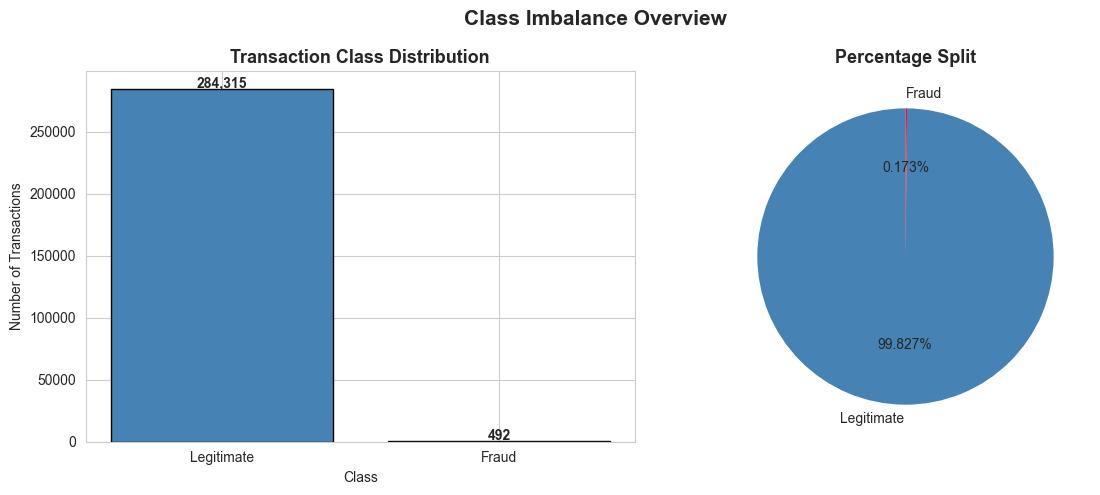

In [ ]:
# Count how many transactions belong to each class
# value_counts() returns the each value in the column
fraud_count = df['Class'].value_counts()[1]  # number of fraud cases
legit_count  = df['Class'].value_counts()[0]  # number of legitimate cases

# Calculate fraud as a percentage of all transactions
fraud_pct = (fraud_count / len(df)) * 100

# Print a summary
print(f'Legitimate transactions : {legit_count:,}  ({100 - fraud_pct:.3f}%)')
print(f'Fraud transactions      : {fraud_count:,}  ({fraud_pct:.3f}%)')

# Create a figure with two side-by-side subplots
# fig = the whole figure, axes = array of the two individual charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart: Bar chart
bars = axes[0].bar(
    ['Legitimate', 'Fraud'],          # x-axis labels
    [legit_count, fraud_count],        # bar heights
    color=['steelblue', 'crimson'],    # blue = legit, red = fraud
    edgecolor='black'                  
)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Class')

# Add the exact count as a label on top of each bar
# zip() pairs each bar with its value so we can loop over both together
for bar, val in zip(bars, [legit_count, fraud_count]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,  # x position: centre of bar
        bar.get_height() + 1000,             # y position: just above bar
        f'{val:,}',                          # the label text
        ha='center', fontweight='bold', fontsize=10
    )

# Right chart: Pie chart 
axes[1].pie(
    [100 - fraud_pct, fraud_pct],          # slice sizes
    labels=['Legitimate', 'Fraud'],         # slice labels
    autopct='%1.3f%%',                      # show percentage inside each slice
    colors=['steelblue', 'crimson'],
    startangle=90,                          
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.001}  # white border between slices
)
axes[1].set_title('Percentage Split', fontsize=13, fontweight='bold')

# overall title for the whole figure
plt.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()  # prevents charts from overlapping
plt.show()

## 6. Transaction Amount Analysis

The `Amount` column records the transaction value in Euros.
We want to understand how amounts differ between fraud and legitimate transactions.


**Why an overlapping histogram?**
The histogram shows where most transactions are concentrated.
fraud and legitimate on the same chart shows whether fraud tends to happen
at different amounts 

--- Amount Statistics ---
Fraud      — Mean: £122.21  | Median: £9.25  | Max: £2125.87
Legitimate — Mean: £88.29  | Median: £22.00  | Max: £25691.16


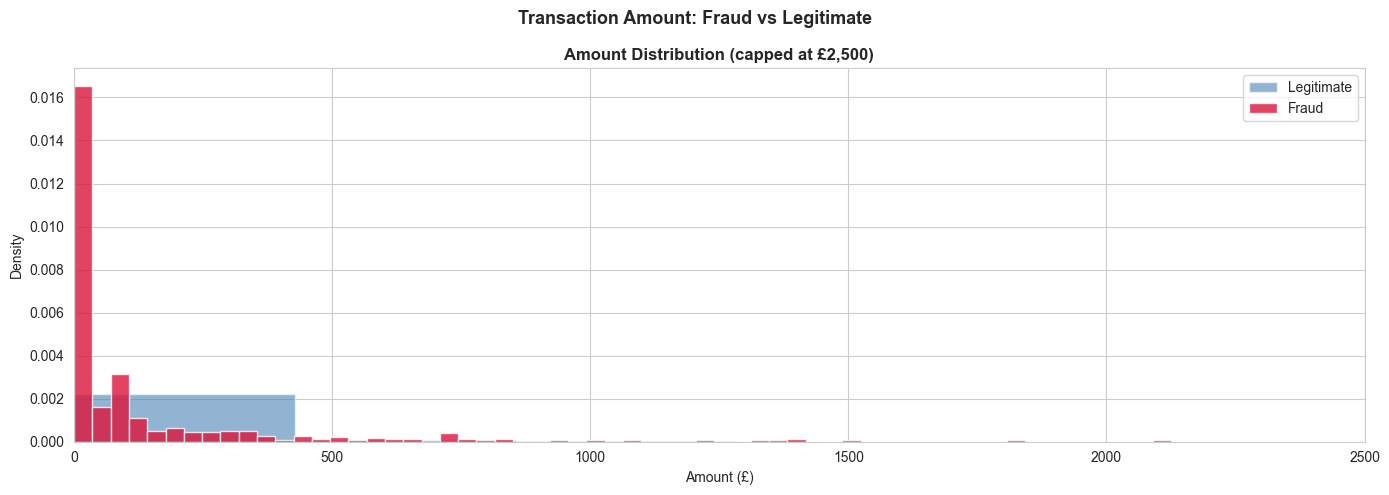

In [ ]:
# Split the dataframe into two separate dataframes — one for each class
# This makes it easier to compare fraud vs legitimate throughout the notebook
fraud_df = df[df['Class'] == 1]  # all fraud transactions
legit_df  = df[df['Class'] == 0]  # all legitimate transactions

# Print statistics for Amount in each class
print('--- Amount Statistics ---')
print(f"Fraud      — Mean: £{fraud_df['Amount'].mean():.2f}  | "
      f"Median: £{fraud_df['Amount'].median():.2f}  | "
      f"Max: £{fraud_df['Amount'].max():.2f}")
print(f"Legitimate — Mean: £{legit_df['Amount'].mean():.2f}  | "
      f"Median: £{legit_df['Amount'].median():.2f}  | "
      f"Max: £{legit_df['Amount'].max():.2f}")

fig, axes = plt.subplots(figsize=(14, 5))


# Overlapping histogram
# despite having very different numbers of transactions
axes.hist(legit_df['Amount'], bins=60, alpha=0.6,
              color='steelblue', label='Legitimate', density=True)
axes.hist(fraud_df['Amount'], bins=60, alpha=0.8,
              color='crimson', label='Fraud', density=True)

# Cap x-axis at £2,500 (very few transactions are above this)
# and it makes the chart easier to read
axes.set_xlim(0, 2500)
axes.set_title('Amount Distribution (capped at £2,500)', fontweight='bold')
axes.set_xlabel('Amount (£)')
axes.set_ylabel('Density')
axes.legend()

plt.suptitle('Transaction Amount: Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Log Transformation of Amount

**What is skewness?**
Skewness measures how symmetric a distribution is

The Amount column has a skewness of ~17 — extremely right-skewed
This means a small number of very large transactions are interputing the distribution
Many machine learning algorithms perform better when features are more normally distributed.

This transformed version will be used as the input feature in the model.

Skewness BEFORE log transform: 16.9777
Skewness AFTER  log transform: 0.1627
(Closer to 0 is better — means more symmetric distribution)


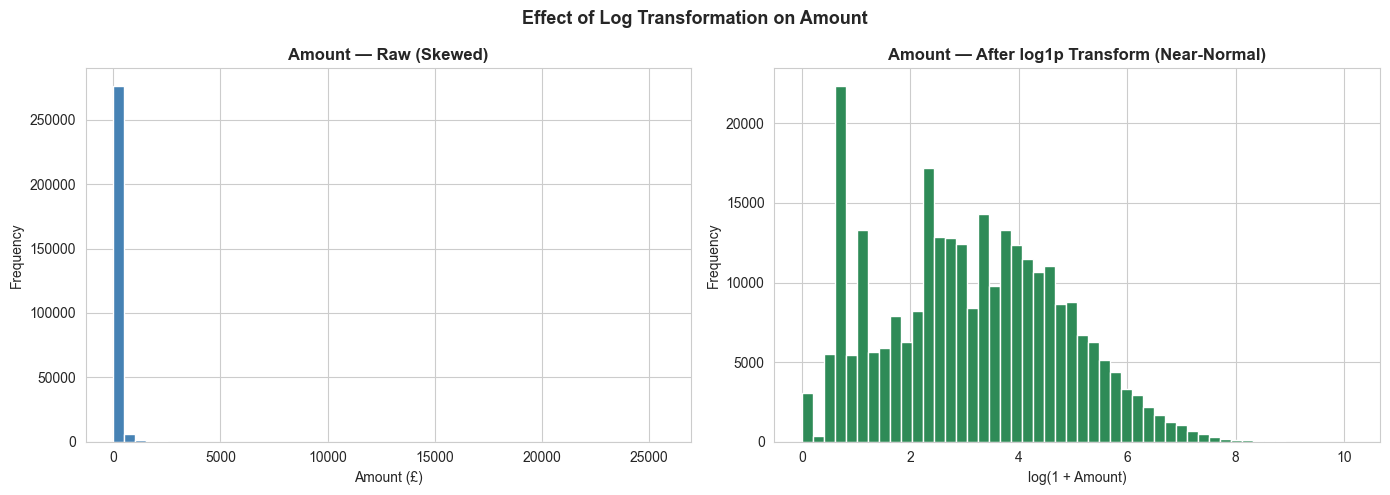

In [ ]:
# Apply log(1 + x) transformation to the Amount column
# We store the result as a new column called Log_Amount
# We keep the original Amount column so we can compare before and after
df['Log_Amount'] = np.log1p(df['Amount'])

# Print skewness before and after to prove the transformation worked
print(f'Skewness BEFORE log transform: {df["Amount"].skew():.4f}')
print(f'Skewness AFTER  log transform: {df["Log_Amount"].skew():.4f}')
print('(Closer to 0 is better — means more symmetric distribution)')

# Plot before and after side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw Amount 
axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Amount — Raw (Skewed)', fontweight='bold')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('Frequency')

# Right: log-transformed Amount 
axes[1].hist(df['Log_Amount'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Amount — After log1p Transform (Near-Normal)', fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Effect of Log Transformation on Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Transaction Time Analysis

`Time` column records how many seconds have elapsed since the first transaction in the dataset.
We convert seconds to 24 hours 

**Why does time matter?**
Fraud may be more likely at certain times 

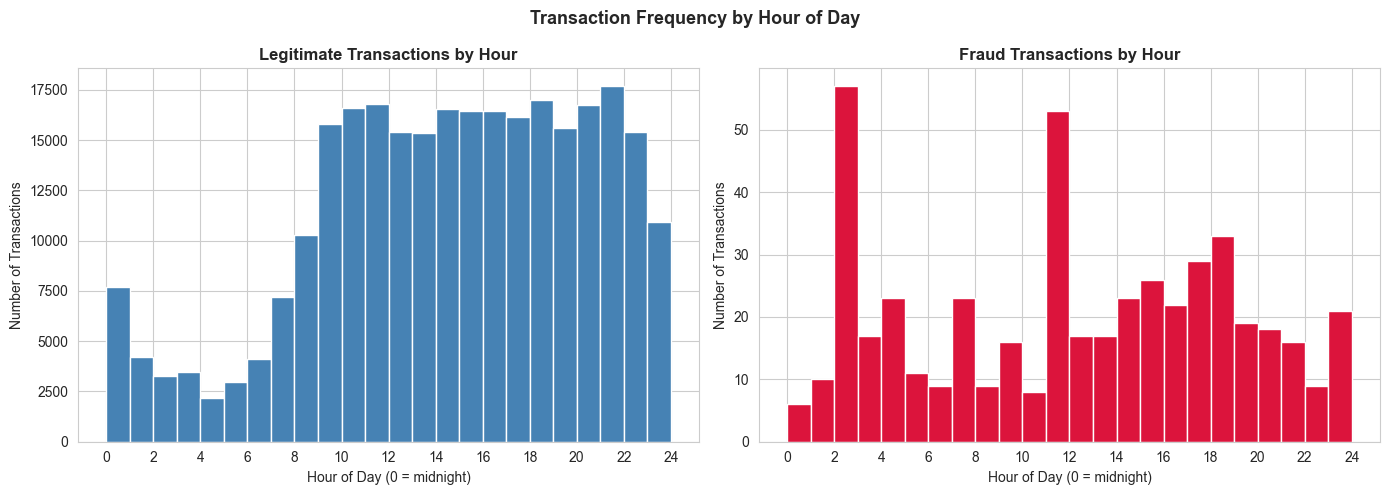

Fraud transactions are most frequent around hour: 11:00


In [ ]:
# Convert seconds to hours
# Dividing by 3600 gives us the hour as a decimal
# .mod(24) makes it to 24hrs so 1:00 becomes 1 etc
df['Hour'] = (df['Time'] / 3600).mod(24)

# Split hours by class for separate plotting
fraud_hours = df[df['Class'] == 1]['Hour']
legit_hours  = df[df['Class'] == 0]['Hour']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Legitimate transactions by hour 
axes[0].hist(
    legit_hours,
    bins=24,            # one bar per hour
    range=(0, 24),      # x-axis 
    edgecolor='white'
)
axes[0].set_title('Legitimate Transactions by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 25, 2))  # tick marks every 2 hours

# Right: Fraud transactions by hour 
axes[1].hist(
    fraud_hours,
    bins=24,
    range=(0, 24),
    color='crimson',
    edgecolor='white'
)
axes[1].set_title('Fraud Transactions by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day (0 = midnight)')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(range(0, 25, 2))

plt.suptitle('Transaction Frequency by Hour of Day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find the hour with the most fraud transactions
peak_hour = int(fraud_hours.value_counts(bins=24).idxmax().mid)
print(f'Fraud transactions are most frequent around hour: {peak_hour}:00')

## 9. Feature Correlation with Fraud

**What is correlation?**
measures the linear relationship between two variables.
It ranges from -1 to +1:
- **+1** — when the feature goes up, fraud probability goes up
- **-1** — when the feature goes up, fraud probability goes down
- **0** — no linear relationship

**Why does this matter for the project?**
This tells us which V features are doing the most work before we even build a model.

Top 5 positively correlated features (higher value = more fraud):
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
Name: Class, dtype: float64

Top 5 negatively correlated features (lower value = more fraud):
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


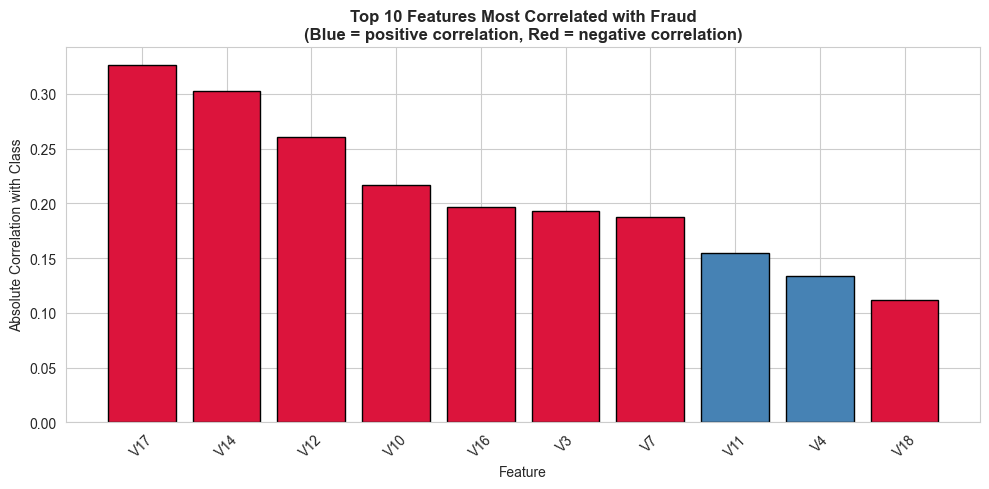

In [ ]:
# Calculate the correlation of every feature with the class column
# .corr() computes the full correlation matrix (all features vs all features)
# ['Class'] selects just the column showing correlation with our target variable
# .sort_values(ascending=False) orders from most positive to most negative
corr_with_class = df.corr()['Class'].sort_values(ascending=False)

# Print the top positively correlated features
# head(6) includes Class itself (which always has correlation = 1.0 with itself)
print('Top 5 positively correlated features (higher value = more fraud):')
print(corr_with_class.head(6))

# Print the top negatively correlated features
print('\nTop 5 negatively correlated features (lower value = more fraud):')
print(corr_with_class.tail(5))

# Take the top 10 features by ABSOLUTE correlation
# [1:11] skips index 0 which is Class itself (correlation = 1.0 with itself)
top_features = corr_with_class.abs().sort_values(ascending=False)[1:11]

# Colour bars red for negative correlation, blue for positive
# This lets us see the direction at a glance
colors = [
    'crimson' if corr_with_class[f] < 0 else 'steelblue'
    for f in top_features.index
]

plt.figure(figsize=(10, 5))
plt.bar(top_features.index, top_features.values,
         color=colors, edgecolor='black')
plt.title(
    'Top 10 Features Most Correlated with Fraud\n(Blue = positive correlation, Red = negative correlation)',
    fontsize=12, fontweight='bold'
)
plt.ylabel('Absolute Correlation with Class')
plt.xlabel('Feature')
plt.xticks(rotation=45)  # rotate labels so they do not overlap
plt.tight_layout()
plt.show()